<a href="https://colab.research.google.com/github/Krishishah7/ai-learning-series/blob/main/04_natural_language_processing/08_sequence_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sequence Models

Traditional machine learning techniques such as Bag of Words and TF-IDF ignore the order of words in a sentence. Even word embeddings represent each word independently.

However, language is sequential. The meaning of a sentence depends not only on the words themselves but also on the order in which they appear.

Sequence models process text one token at a time while preserving the relationships between words. Before training sequence models such as RNNs, LSTMs, or GRUs, text must first be converted into sequences of integers and adjusted to a fixed length using padding or truncation.

These preprocessing steps form the foundation for modern deep learning models in Natural Language Processing.

In [1]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import pandas as pd

In [2]:
sentences = [

    "Machine learning is amazing",

    "Deep learning powers AI",

    "Natural language processing is interesting",

    "Artificial intelligence transforms industries"

]

for sentence in sentences:
    print(sentence)

Machine learning is amazing
Deep learning powers AI
Natural language processing is interesting
Artificial intelligence transforms industries


In [3]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts(sentences)

word_index = tokenizer.word_index

print(word_index)

{'learning': 1, 'is': 2, 'machine': 3, 'amazing': 4, 'deep': 5, 'powers': 6, 'ai': 7, 'natural': 8, 'language': 9, 'processing': 10, 'interesting': 11, 'artificial': 12, 'intelligence': 13, 'transforms': 14, 'industries': 15}


In [4]:
sequences = tokenizer.texts_to_sequences(sentences)

print(sequences)

[[3, 1, 2, 4], [5, 1, 6, 7], [8, 9, 10, 2, 11], [12, 13, 14, 15]]


In [5]:
padded_sequences = pad_sequences(

    sequences,

    padding="post"

)

print(padded_sequences)

[[ 3  1  2  4  0]
 [ 5  1  6  7  0]
 [ 8  9 10  2 11]
 [12 13 14 15  0]]


In [6]:
long_sentences = [

    "Artificial intelligence is transforming healthcare rapidly"

]

long_sequence = tokenizer.texts_to_sequences(long_sentences)

truncated = pad_sequences(

    long_sequence,

    maxlen=4,

    truncating="post"

)

print(truncated)

[[ 0 12 13  2]]


In [7]:
sequence_df = pd.DataFrame({

    "Sentence": sentences,

    "Sequence": sequences

})

sequence_df

,Sentence,Sequence
0,Machine learning is amazing,"[3, 1, 2, 4]"
1,Deep learning powers AI,"[5, 1, 6, 7]"
2,Natural language processing is interesting,"[8, 9, 10, 2, 11]"
3,Artificial intelligence transforms industries,"[12, 13, 14, 15]"


In [8]:
comparison = pd.DataFrame({

    "Raw Text":[

        "Variable length",

        "Cannot feed directly into neural networks",

        "Human readable"

    ],

    "Padded Sequence":[

        "Fixed length",

        "Suitable for deep learning",

        "Numerical representation"

    ]

})

comparison

,Raw Text,Padded Sequence
0,Variable length,Fixed length
1,Cannot feed directly into neural networks,Suitable for deep learning
2,Human readable,Numerical representation


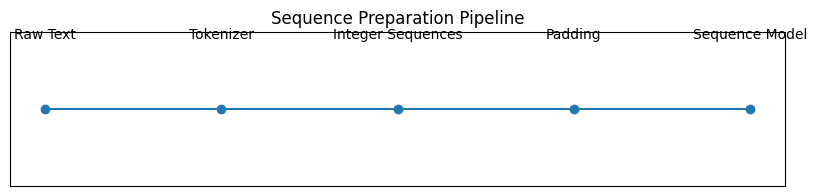

In [9]:
import matplotlib.pyplot as plt

steps = [

    "Raw Text",

    "Tokenizer",

    "Integer Sequences",

    "Padding",

    "Sequence Model"

]

plt.figure(figsize=(10,2))

plt.plot(

    range(len(steps)),

    [1]*len(steps),

    marker="o"

)

for i, step in enumerate(steps):

    plt.text(i,1.05,step,ha="center")

plt.xticks([])

plt.yticks([])

plt.title("Sequence Preparation Pipeline")

plt.show()